<a href="https://colab.research.google.com/github/sabahoth01/Machine-learning-tasks/blob/brunnotte%2Ftask1/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задача 3. Сравнение методов классификации

### Васаулюа Брюнотт Тази  М81

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
custom_colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
import warnings
from scipy.special import expit
from sklearn.base import BaseEstimator
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from scipy.io import arff

Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров.

 (**+2 балла**) Реализовать еще один из методов классификации и добавить его в сравнение.

- SVM

- Logistic Regression

In [125]:
class MyLogRegClassifier(BaseEstimator):
    def __init__(self, alpha=1e-1, lr=1e-2, num_iter=1000):
        self._alpha = alpha
        self._lr = lr
        self._num_iter = num_iter

    def fit(self, X_train, y_train):
        num_samples, num_features = X_train.shape

        self.weights = np.zeros(num_features, )
        self.bias = 0

        for iter in range(self._num_iter):
            preds = expit(np.dot(X_train, self.weights) + self.bias)
            errors = preds - y_train

            w_grad = (2 / num_samples) * np.dot(X_train.T, errors) + self._alpha * self.weights
            b_grad = (2 / num_samples) * np.sum(errors)

            self.weights -= self._lr * w_grad
            self.bias -= self._lr * b_grad

        return self

    def predict(self, X_test):
        pred_probs = expit(np.dot(X_test, self.weights) + self.bias)
        return np.where(pred_probs < 0.5, 0, 1)

    def get_params(self, deep=True):
        return {'alpha': self._alpha,
                'lr': self._lr,
                'num_iter': self._num_iter}

    def set_params(self, **parameters):
        for param, value in parameters.items():
            setattr(self, param, value)
        return self

In [126]:
class MySVMClassifier(BaseEstimator):
    def __init__(self, alpha=1e-1, Lambda=1e-1, num_iter=10):
        self._alpha = alpha
        self._lambda = Lambda
        self._num_iter = num_iter

    def fit(self, X_train, y_train):
        y_train_labels = np.where(y_train <= 0, -1, 1)
        self.weights = np.zeros(X_train.shape[1])
        self.bias = 0
        for iter in range(self._num_iter):
            for i, x_i in enumerate(X_train):
                dw = 0
                db = 0
                M = y_train_labels[i] * (np.dot(x_i, self.weights) - self.bias)
                if  M >= 1:
                    dw = 2 * self._lambda * self.weights
                    db = 0
                else:
                    dw = 2 * self._lambda * self.weights - np.dot(x_i, y_train_labels[i])
                    db = y_train_labels[i]

                self.weights -= self._alpha * dw
                self.bias -= self._alpha * db

        return self

    def predict(self, X_test):
        labels = np.sign(X_test @ self.weights - self.bias)
        preds = np.where(labels <= -1, 0, 1)
        return preds

    def get_params(self, deep=True):
        return {'alpha': self._alpha,
                'Lambda': self._lambda,
                'num_iter': self._num_iter}

    def set_params(self, **parameters):
        for param, value in parameters.items():
            setattr(self, param, value)
        return self

Взять данные для предсказания заболеваний сердца [тут](https://github.com/rustam-azimov/ml-course/tree/main/data/heart_disease) (целевой признак для предсказания --- **target**). Демо блокнот с анализом этих данных можно найти [тут](https://github.com/rustam-azimov/ml-course/blob/main/practice/practice07_knn_nb/practice07_part02_classification_heart_disease_demo.ipynb).

- Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи классификации.
- При необходимости выполнить полезные преобразования данных (например, трансформировать категариальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).

In [127]:
df = pd.read_csv(r"/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


Описание датасета:
- age - age in years
- sex - (1 = male; 0 = female)
- cp - chest pain type
- trestbps - resting blood pressure (in mm Hg on admission to the hospital)
- chol - serum cholestoral in mg/dl
- fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- restecg - resting electrocardiographic results
- thalach - maximum heart rate achieved
- exang - exercise induced angina (1 = yes; 0 = no)
- oldpeak - ST depression induced by exercise relative to rest
- slope - the slope of the peak exercise ST segment
- ca - number of major vessels (0-3) colored by flourosopy
- thal - 3 = normal; 6 = fixed defect; 7 = reversable defect
- target - have disease or not (1=yes, 0=no)
#### Необходимо решить задачу классификации и научиться предсказывать целовой признак target (имеет ли пациент заболевание сердца).

In [128]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## EDA

<Axes: xlabel='target', ylabel='count'>

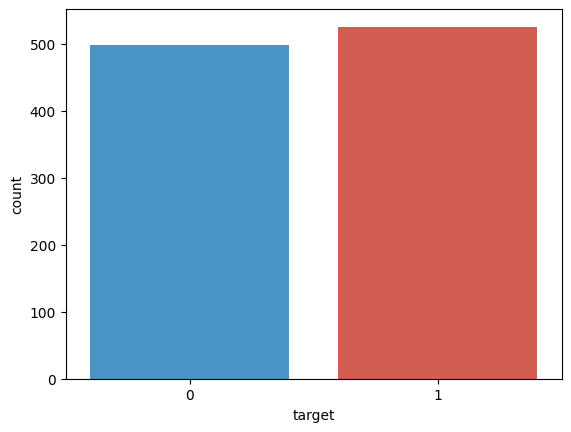

In [130]:
sns.countplot(x="target", data=df, palette=custom_colors)

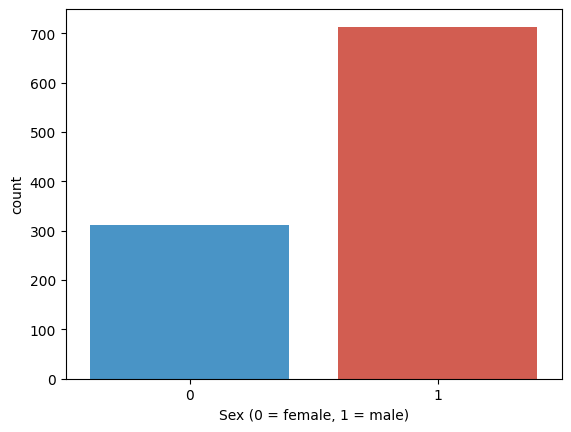

In [131]:
sns.countplot(x='sex', data=df, palette=custom_colors)
plt.xlabel("Sex (0 = female, 1 = male)")
plt.show()

Датасет содержит больше данных пациентов мужского пола.

In [132]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


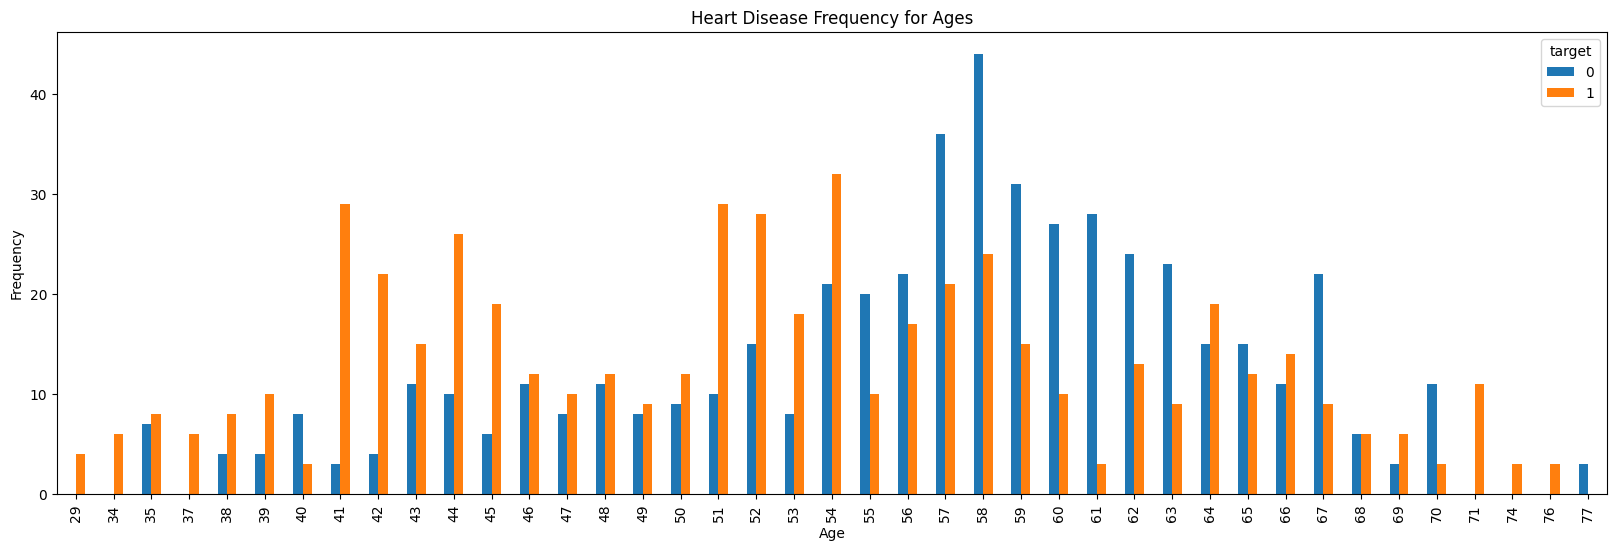

In [133]:
pd.crosstab(df.age,df.target).plot(kind="bar", figsize=(20, 6))
plt.title('Heart Disease Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Заметен резкий скачок пациентов с заболеванем в возрасте применрно 40 лет.  Также заметно, что примерно в возрасте 50-60 лет высокое количество пациентов без заболеваний.

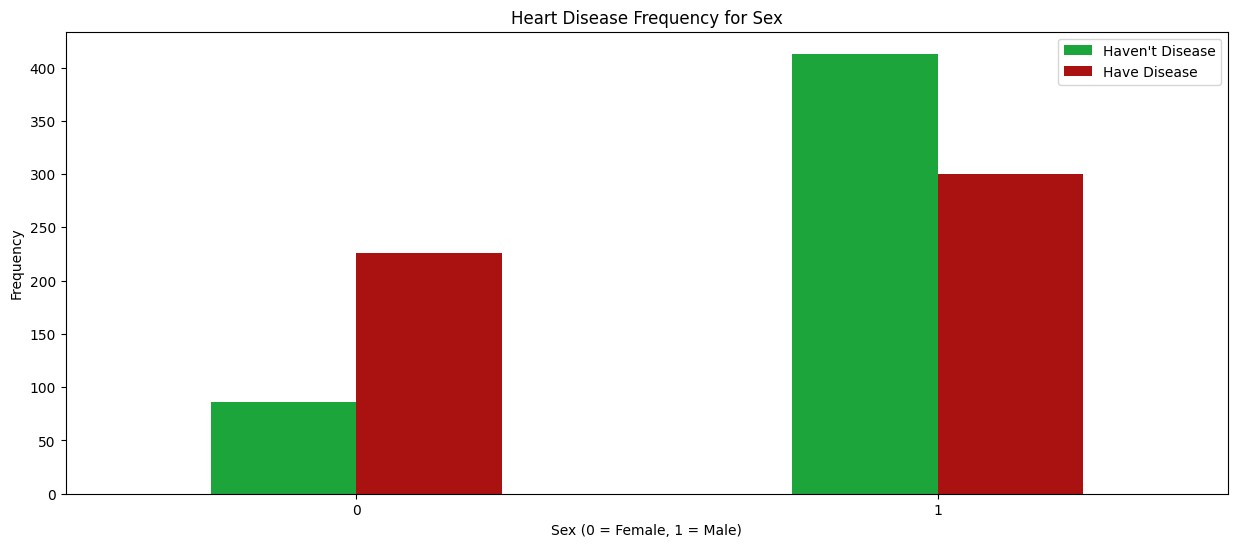

In [134]:
pd.crosstab(df.sex,df.target).plot(kind="bar", figsize=(15, 6), color=['#1CA53B', '#AA1111' ])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.xticks(rotation=0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency')
plt.show()

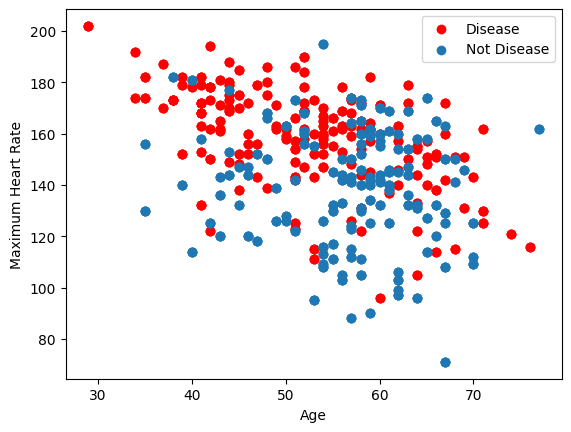

In [135]:
plt.scatter(x=df.age[df.target==1], y=df.thalach[(df.target==1)], c="red")
plt.scatter(x=df.age[df.target==0], y=df.thalach[(df.target==0)])
plt.legend(["Disease", "Not Disease"])
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.show()

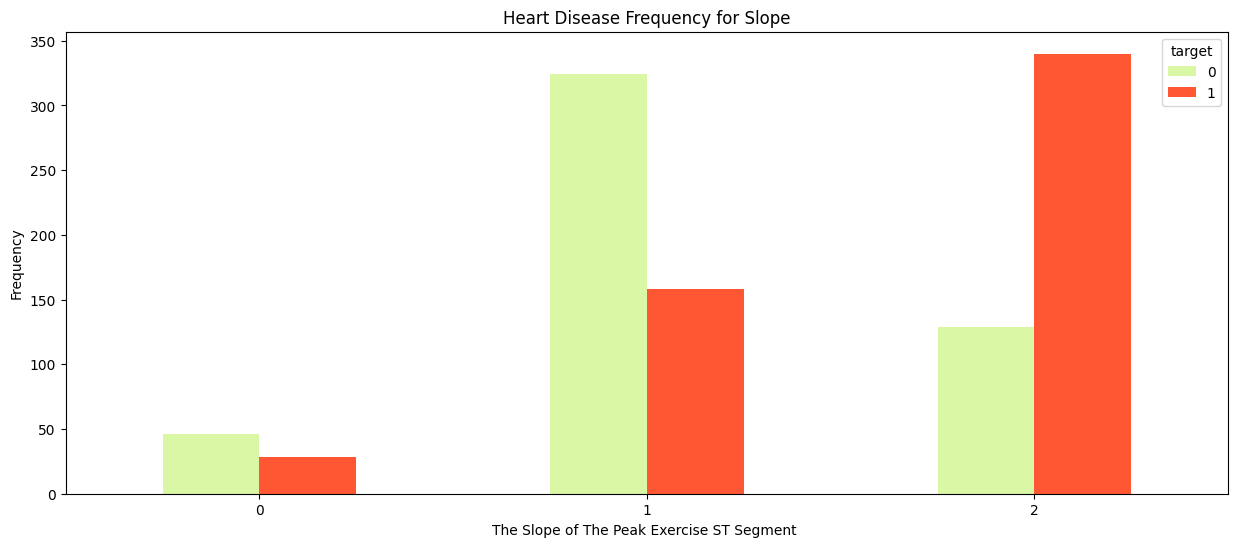

In [136]:
pd.crosstab(df.slope,df.target).plot(kind="bar", figsize=(15, 6), color=['#DAF7A6','#FF5733' ])
plt.title('Heart Disease Frequency for Slope')
plt.xlabel('The Slope of The Peak Exercise ST Segment ')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()

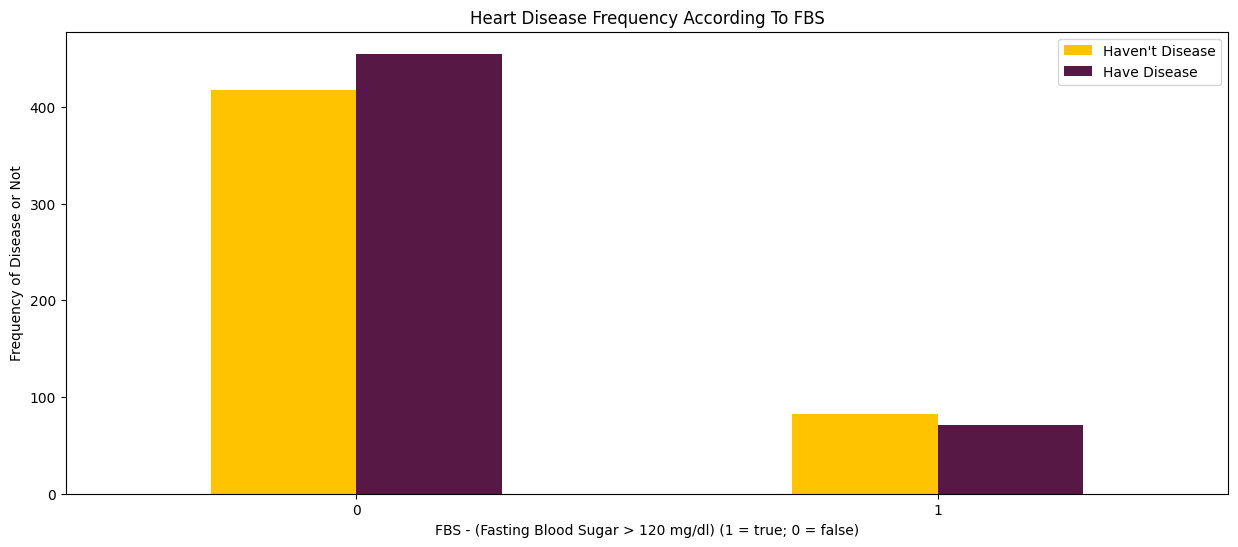

In [137]:
pd.crosstab(df.fbs,df.target).plot(kind="bar", figsize=(15, 6), color=['#FFC300','#581845' ])
plt.title('Heart Disease Frequency According To FBS')
plt.xlabel('FBS - (Fasting Blood Sugar > 120 mg/dl) (1 = true; 0 = false)')
plt.xticks(rotation = 0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency of Disease or Not')
plt.show()

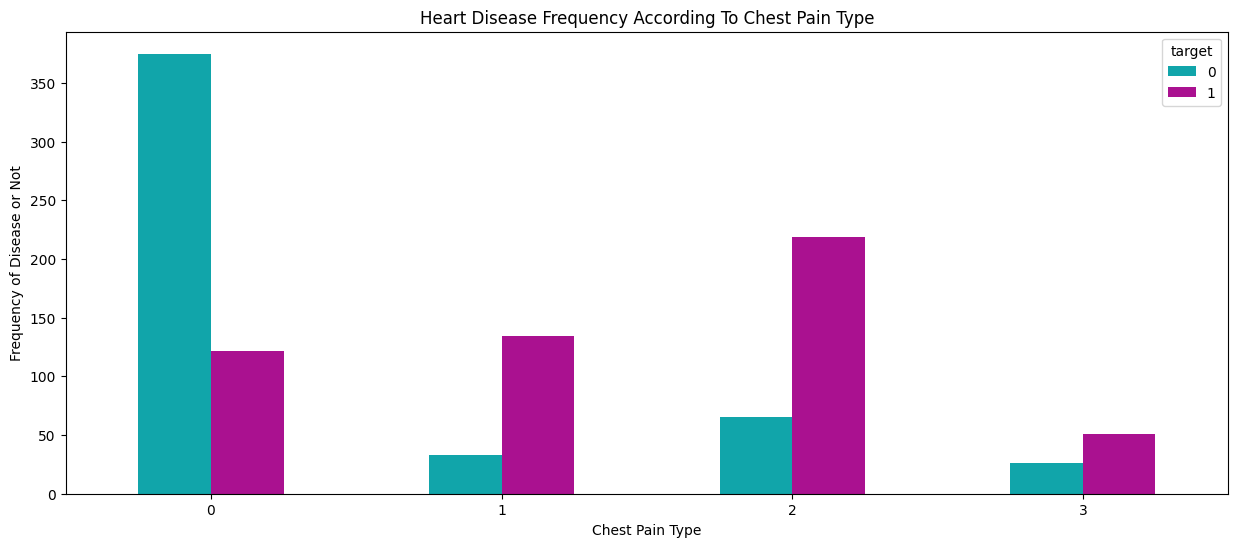

In [138]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(15, 6), color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

### Преобразование категориальных признаков

In [139]:
cp_dum = pd.get_dummies(df['cp'], prefix = "cp")
thal_dum = pd.get_dummies(df['thal'], prefix = "thal")
slope_dum = pd.get_dummies(df['slope'], prefix = "slope")
frames = [df, cp_dum, thal_dum, slope_dum]
df = pd.concat(frames, axis = 1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,0,125,212,0,1,168,0,1.0,...,False,False,False,False,False,False,True,False,False,True
1,53,1,0,140,203,1,0,155,1,3.1,...,False,False,False,False,False,False,True,True,False,False
2,70,1,0,145,174,0,1,125,1,2.6,...,False,False,False,False,False,False,True,True,False,False
3,61,1,0,148,203,0,1,161,0,0.0,...,False,False,False,False,False,False,True,False,False,True
4,62,0,0,138,294,1,1,106,0,1.9,...,False,False,False,False,False,True,False,False,True,False


In [140]:
df = df.drop(columns = ['cp', 'thal', 'slope'])
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,...,False,False,False,False,False,False,True,False,False,True
1,53,1,140,203,1,0,155,1,3.1,0,...,False,False,False,False,False,False,True,True,False,False
2,70,1,145,174,0,1,125,1,2.6,0,...,False,False,False,False,False,False,True,True,False,False
3,61,1,148,203,0,1,161,0,0.0,1,...,False,False,False,False,False,False,True,False,False,True
4,62,0,138,294,1,1,106,0,1.9,3,...,False,False,False,False,False,True,False,False,True,False


Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания от Вашей реализации на выделенной заранее тестовой выборке.

In [141]:
y = df['target']
X = df.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=37)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Повторить предыдущий пункт для библиотечных реализаций (например, из **sklearn**) всех пройденных методов классификации (**logistic regression, svm, knn, naive bayes, decision tree**).
Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.

In [142]:
lr = LogisticRegression(random_state=37)

C_grid = [1e-3, 1e-2, 1e-1]
searcher = GridSearchCV(lr, {'C': C_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_lr = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.1}
Best score:  0.8463414634146341


In [143]:
svc = SVC(random_state=37)

C_grid = [0.1, 0.25, 0.5, 0.75, 1, 2]
kernel_grid = ["linear", "rbf"]
gamma_grid = ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1, 1]

searcher = GridSearchCV(svc, {'C': C_grid, 'kernel': kernel_grid, 'gamma': gamma_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.5, 'gamma': 1, 'kernel': 'rbf'}
Best score:  0.9792682926829268


In [144]:
my_svc = MySVMClassifier()  # собственная реализация

lambda_grid = np.linspace(1e-4, 1e-1, 5)
alpha_grid = np.linspace(1e-4, 1e-1, 5)

searcher = GridSearchCV(my_svc, {'Lambda': lambda_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'Lambda': 0.0001, 'alpha': 0.0001}
Best score:  0.7987804878048781


In [145]:
mlrc = MyLogRegClassifier()  # собственная реализация

lr_grid = [1e-3, 1e-2, 1e-1]
alpha_grid = [1e-3, 1e-2, 1e-1]

searcher = GridSearchCV(mlrc, {'lr': lr_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_lrc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'alpha': 0.001, 'lr': 0.001}
Best score:  0.8536585365853657


In [146]:
knc = KNeighborsClassifier()

n_neighbors_grid = np.arange(1, 20, 2)
weights_grid = ['distance', 'uniform']

searcher = GridSearchCV(knc, {'n_neighbors': n_neighbors_grid, 'weights': weights_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_knc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'n_neighbors': 19, 'weights': 'distance'}
Best score:  0.9902439024390244


In [147]:
var_smoothing_grid = np.logspace(0, -10, 100)

gnb = GaussianNB()
searcher = GridSearchCV(gnb, {'var_smoothing': var_smoothing_grid}, scoring='accuracy', cv=5)

searcher = searcher.fit(X_train_scaled, y_train)
best_gnb = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'var_smoothing': 0.7924828983539173}
Best score:  0.8426829268292682


In [148]:
dtc = DecisionTreeClassifier(random_state=37)

criterion_grid = ["gini", "entropy", "log_loss"]
max_features_grid = [None, 0.5, 2, 5, 10]
min_samples_split_grid = [2, 3, 4, 5, 10]

searcher = GridSearchCV(dtc, {'criterion': criterion_grid, 'max_features': max_features_grid, 'min_samples_split': min_samples_split_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_dtc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'criterion': 'entropy', 'max_features': None, 'min_samples_split': 2}
Best score:  0.9865853658536585


In [149]:
y_my_lr = best_my_lrc.predict(X_test_scaled)
y_my_svc = best_my_svc.predict(X_test_scaled)

y_lr = best_lr.predict(X_test_scaled)
y_svc = best_svc.predict(X_test_scaled)
y_knc = best_knc.predict(X_test_scaled)
y_gnb = best_gnb.predict(X_test_scaled)
y_dtc = best_dtc.predict(X_test_scaled)

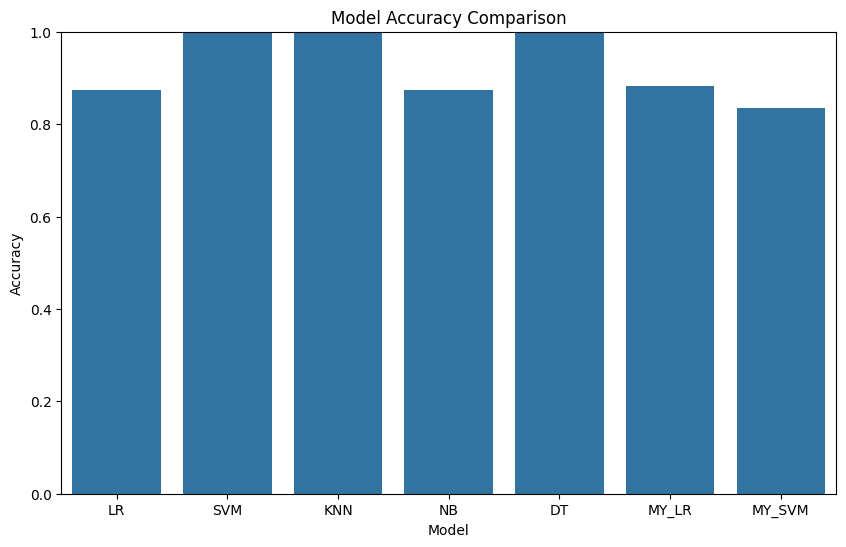

In [150]:

scores = {
    'LR': accuracy_score(y_test, y_lr),
    'SVM': accuracy_score(y_test, y_svc),
    'KNN': accuracy_score(y_test, y_knc),
    'NB': accuracy_score(y_test, y_gnb),
    'DT': accuracy_score(y_test, y_dtc),
    'MY_LR': accuracy_score(y_test, y_my_lr),
    'MY_SVM': accuracy_score(y_test, y_my_svc)
}

# Create a DataFrame for better visualization
scores_df = pd.DataFrame(list(scores.items()), columns=['Model', 'Accuracy'])

# Plotting the scores using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=scores_df)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)  # Set y-axis limits to show accuracy percentage
plt.show()

In [151]:
scores_df

,Model,Accuracy
0,LR,0.873171
1,SVM,1.000000
2,KNN,1.000000
3,NB,0.873171
4,DT,1.000000
5,MY_LR,0.882927
6,MY_SVM,0.834146


Confusion Matrix

In [152]:

cm_lr = confusion_matrix(y_test, y_lr)
cm_knn = confusion_matrix(y_test, y_knc)
cm_svm = confusion_matrix(y_test, y_svc)
cm_nb = confusion_matrix(y_test, y_gnb)
cm_dtc = confusion_matrix(y_test, y_dtc)
cm_my_lr = confusion_matrix(y_test, y_my_lr)
cm_my_svc = confusion_matrix(y_test, y_my_svc)

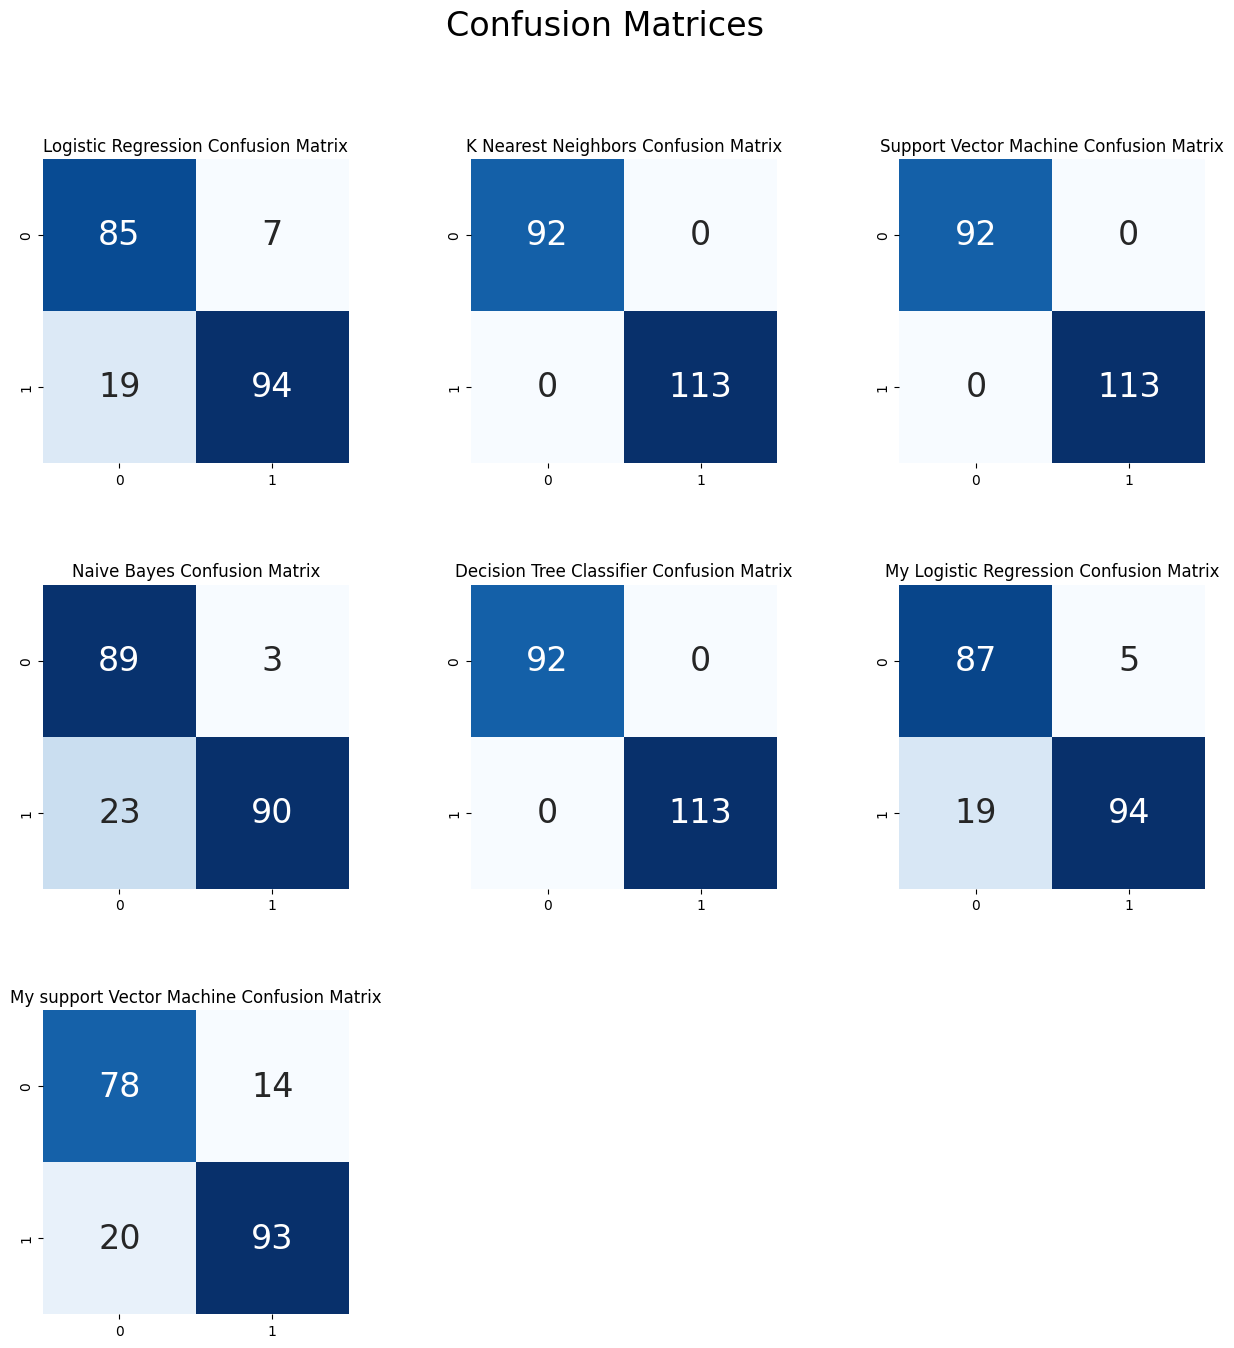

In [153]:
plt.figure(figsize=(15, 15))

plt.suptitle("Confusion Matrices", fontsize=24)
plt.subplots_adjust(wspace = 0.4, hspace= 0.4)

plt.subplot(3,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knn,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_nb,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dtc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,6)
plt.title("My Logistic Regression Confusion Matrix")
sns.heatmap(cm_my_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,7)
plt.title("My support Vector Machine Confusion Matrix")
sns.heatmap(cm_my_svc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.show()

Вывод: на этом датасете точнее всего оказались модели Decision tree,SVM и KNN. За ними идут Naive Bayes, Logistic Regression и собственная реализация My Logitic Regression. Наименьшую точность показала модель My SVM.

 (**+3 балла**) Найти данные, на которых интересно будет решать задачу классификации. Повторить все пункты задания на новых данных.

Dataset:[
Rice (Cammeo and Osmancik)](https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik) из UC.

Датасет Rice (Cammeo and Osmancik) представляет собой набор данных, связанный с анализом и классификацией риса.

Информация о признаках:

- Площадь: Возвращает количество пикселей в пределах границ зерна риса.
- Периметр: Вычисляет окружность, рассчитывая расстояние между пикселями вокруг границ зерна риса.
- Длина главной оси: Самая длинная линия, которая может быть проведена на зерне риса, т.е. расстояние главной оси.
Длина малой оси: Самая короткая линия, которая может быть проведена на зерне риса, т.е. расстояние малой оси.
- Эксцентриситет: Измеряет, насколько круглая эллипса, которая имеет те же моменты, что и зерно риса.
- Выпуклая площадь: Возвращает количество пикселей самого маленького выпуклого оболочки области, образованной зерном риса.
- Протяженность: Возвращает отношение области, образованной зерном риса, к пикселям ограничивающего прямоугольника.
- Класс: Commeo и Osmancik.

In [154]:

arff_file = arff.loadarff('/content/rice.arff')
data = pd.DataFrame(arff_file[0])
daa= data['Class'] = data['Class'].apply(lambda x: x.decode('utf-8'))
data

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441.0,415.858002,170.486771,85.756592,0.864280,11628.0,0.681012,Osmancik
3806,11625.0,421.390015,167.714798,89.462570,0.845850,11904.0,0.694279,Osmancik
3807,12437.0,442.498993,183.572922,86.801979,0.881144,12645.0,0.626739,Osmancik
3808,9882.0,392.296997,161.193985,78.210480,0.874406,10097.0,0.659064,Osmancik


## EDA

In [155]:
data.isnull().sum()

,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Eccentricity,0
Convex_Area,0
Extent,0
Class,0


In [157]:
data.groupby('Class').mean()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
Class,,,,,,,
Cammeo,14162.892025,487.438942,205.478589,88.767532,0.901047,14494.426994,0.651420
Osmancik,11549.783486,429.415505,176.287755,84.479042,0.876271,11799.585780,0.669796


<Axes: xlabel='Class', ylabel='count'>

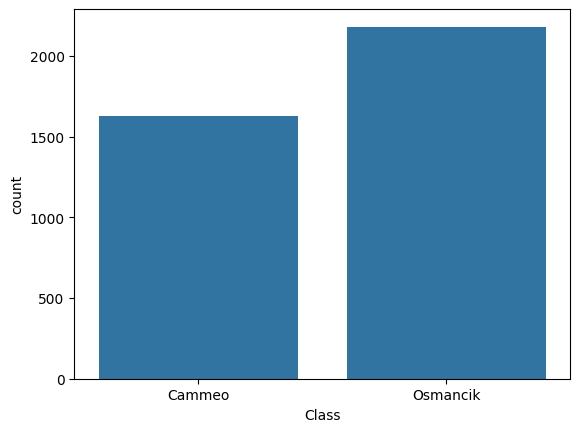

In [158]:
sns.countplot(x="Class", data=data)

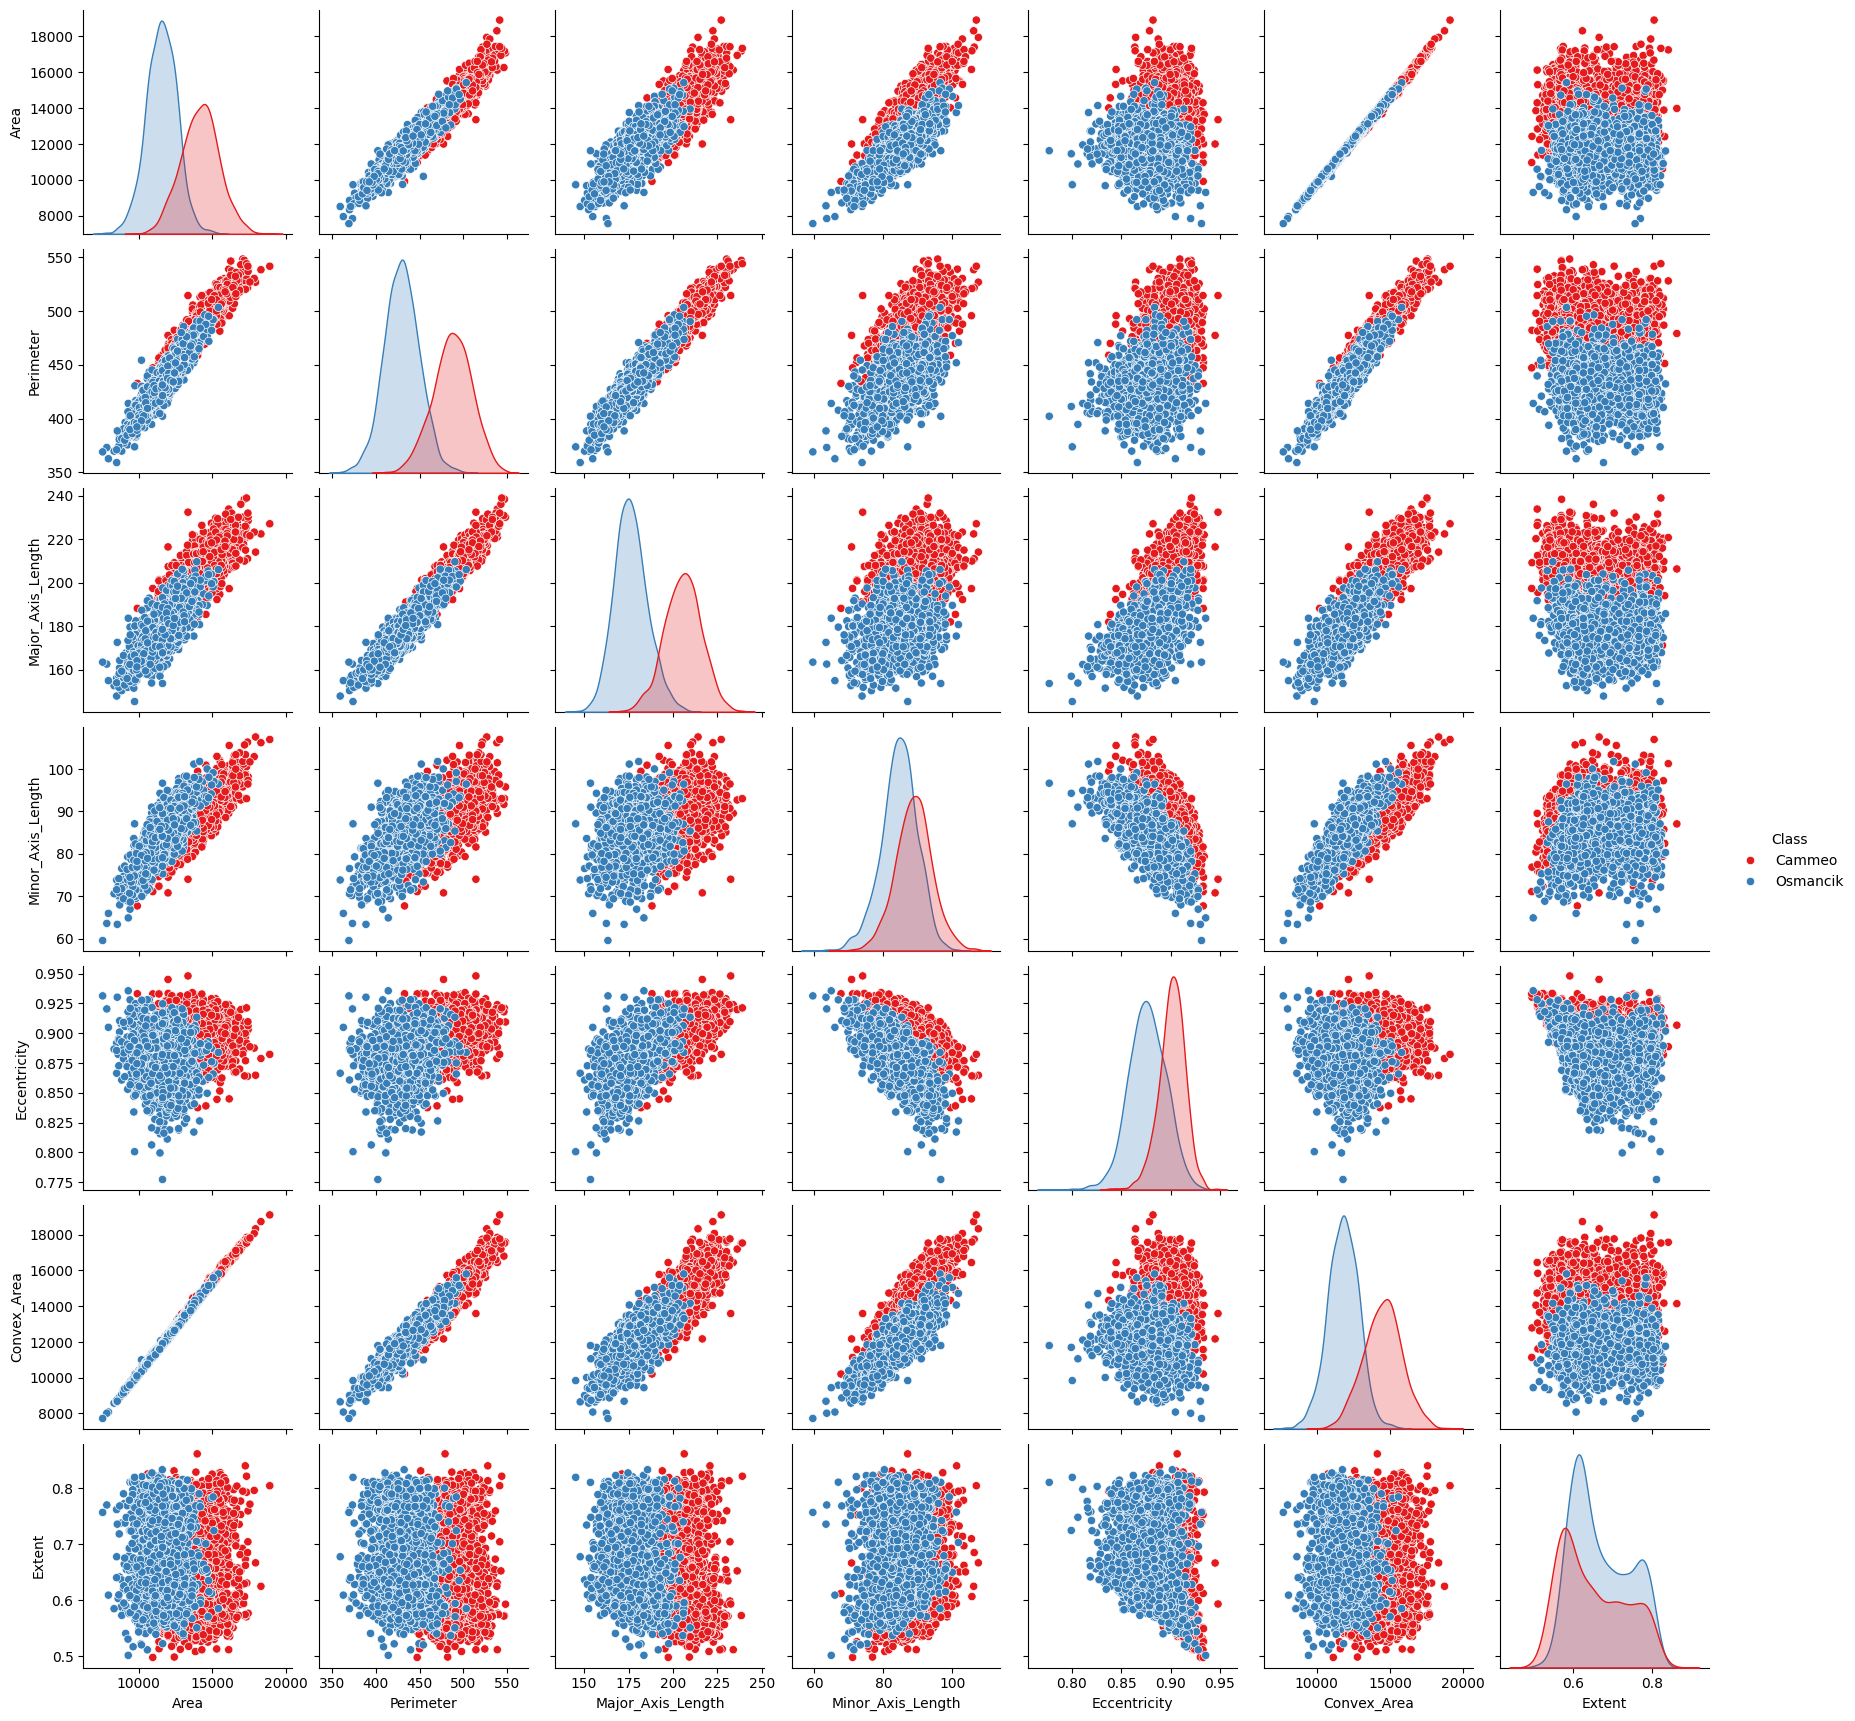

In [159]:
sns.pairplot(data, hue='Class', palette="Set1")

Вывод:
- Отметим, что по всем признакам можно довольно хорошо предсказывать целевой признак.
- Osmancik найболее класс риса в датасете

Преобразование категориальных признаков

In [160]:
data['Class'] = data['Class'].map({'Cammeo': 0, 'Osmancik': 1})

data.to_csv('/content/cleaned.csv', index=False, sep=',', encoding='utf-8')
df = pd.read_csv('/content/cleaned.csv')
df

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,0
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,0
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,0
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,0
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,0
...,...,...,...,...,...,...,...,...
3805,11441.0,415.858002,170.486771,85.756592,0.864280,11628.0,0.681012,1
3806,11625.0,421.390015,167.714798,89.462570,0.845850,11904.0,0.694279,1
3807,12437.0,442.498993,183.572922,86.801979,0.881144,12645.0,0.626739,1
3808,9882.0,392.296997,161.193985,78.210480,0.874406,10097.0,0.659064,1


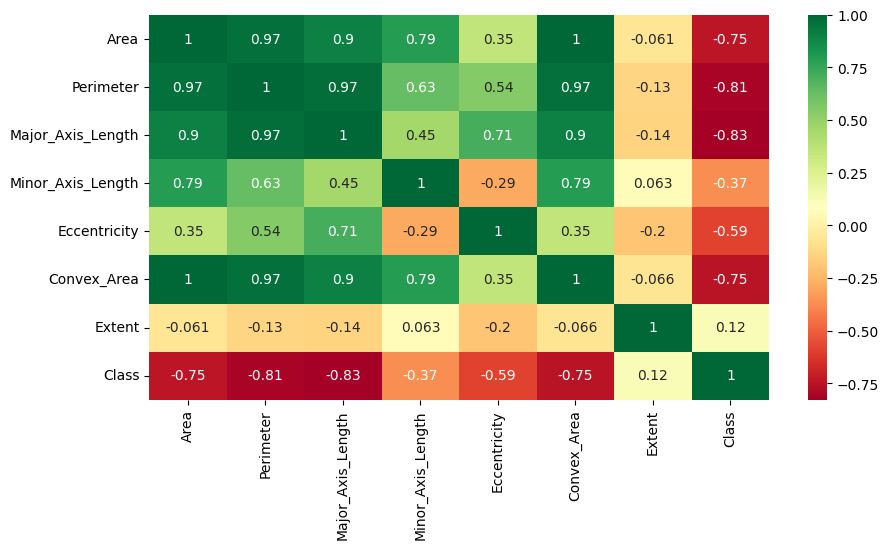

In [161]:
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
fig = plt.gcf()
fig.set_size_inches(10, 5)
plt.show()

Отметим, что area, major_axis_lenght, minor_axis_lenght, convex_area,perimeter -- признаки, описывающие геометрические параметры риса, поэтому они сильно коррелируют между собой.

Training

In [162]:
y = df['Class']
X = df.drop(columns=['Class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=37)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [163]:
lr = LogisticRegression(random_state=37)

C_grid = [1e-3, 1e-2, 1e-1]
searcher = GridSearchCV(lr, {'C': C_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_lr = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.01}
Best score:  0.9288007752563999


In [164]:
svc = SVC(random_state=37)

C_grid = [0.1, 0.25, 0.5, 0.75, 1, 2]
kernel_grid = ["linear", "rbf"]
gamma_grid = ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1, 1]

searcher = GridSearchCV(svc, {'C': C_grid, 'kernel': kernel_grid, 'gamma': gamma_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
Best score:  0.9304428113811947


In [165]:
my_svc = MySVMClassifier()  # собственная реализация

lambda_grid = np.linspace(1e-4, 1e-1, 5)
alpha_grid = np.linspace(1e-4, 1e-1, 5)

searcher = GridSearchCV(my_svc, {'Lambda': lambda_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'Lambda': 0.0001, 'alpha': 0.0001}
Best score:  0.9114134969985732


In [166]:
mlrc = MyLogRegClassifier()  # собственная реализация

lr_grid = [1e-3, 1e-2, 1e-1]
alpha_grid = [1e-3, 1e-2, 1e-1]

searcher = GridSearchCV(mlrc, {'lr': lr_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_lrc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'alpha': 0.001, 'lr': 0.001}
Best score:  0.9281434224339821


In [167]:
knc = KNeighborsClassifier()

n_neighbors_grid = np.arange(1, 20, 2)
weights_grid = ['distance', 'uniform']

searcher = GridSearchCV(knc, {'n_neighbors': n_neighbors_grid, 'weights': weights_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_knc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'n_neighbors': 19, 'weights': 'uniform'}
Best score:  0.9307696034886537


In [168]:
var_smoothing_grid = np.logspace(0, -10, 100)

gnb = GaussianNB()
searcher = GridSearchCV(gnb, {'var_smoothing': var_smoothing_grid}, scoring='accuracy', cv=5)

searcher = searcher.fit(X_train_scaled, y_train)
best_gnb = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'var_smoothing': 0.19630406500402708}
Best score:  0.9163347600204581


In [169]:
dtc = DecisionTreeClassifier(random_state=37)

criterion_grid = ["gini", "entropy", "log_loss"]
max_features_grid = [None, 0.5, 2, 5, 10]
min_samples_split_grid = [2, 3, 4, 5, 10]

searcher = GridSearchCV(dtc, {'criterion': criterion_grid, 'max_features': max_features_grid, 'min_samples_split': min_samples_split_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_dtc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'criterion': 'entropy', 'max_features': 0.5, 'min_samples_split': 5}
Best score:  0.9005884411424263


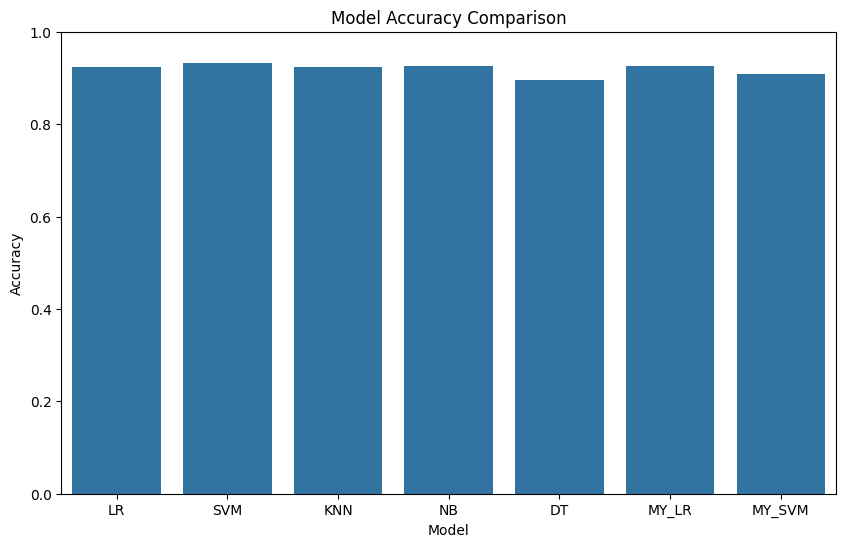

In [170]:
y_my_lr = best_my_lrc.predict(X_test_scaled)
y_my_svc = best_my_svc.predict(X_test_scaled)

y_lr = best_lr.predict(X_test_scaled)
y_svc = best_svc.predict(X_test_scaled)
y_knc = best_knc.predict(X_test_scaled)
y_gnb = best_gnb.predict(X_test_scaled)
y_dtc = best_dtc.predict(X_test_scaled)
scores = {
    'LR': accuracy_score(y_test, y_lr),
    'SVM': accuracy_score(y_test, y_svc),
    'KNN': accuracy_score(y_test, y_knc),
    'NB': accuracy_score(y_test, y_gnb),
    'DT': accuracy_score(y_test, y_dtc),
    'MY_LR': accuracy_score(y_test, y_my_lr),
    'MY_SVM': accuracy_score(y_test, y_my_svc)
}

# Create a DataFrame for better visualization
scores_df = pd.DataFrame(list(scores.items()), columns=['Model', 'Accuracy'])

# Plotting the scores using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=scores_df)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)  # Set y-axis limits to show accuracy percentage
plt.show()

In [171]:
scores_df

,Model,Accuracy
0,LR,0.923885
1,SVM,0.933071
2,KNN,0.922572
3,NB,0.925197
4,DT,0.896325
5,MY_LR,0.925197
6,MY_SVM,0.909449


In [172]:

cm_lr = confusion_matrix(y_test, y_lr)
cm_knn = confusion_matrix(y_test, y_knc)
cm_svm = confusion_matrix(y_test, y_svc)
cm_nb = confusion_matrix(y_test, y_gnb)
cm_dtc = confusion_matrix(y_test, y_dtc)
cm_my_lr = confusion_matrix(y_test, y_my_lr)
cm_my_svc = confusion_matrix(y_test, y_my_svc)

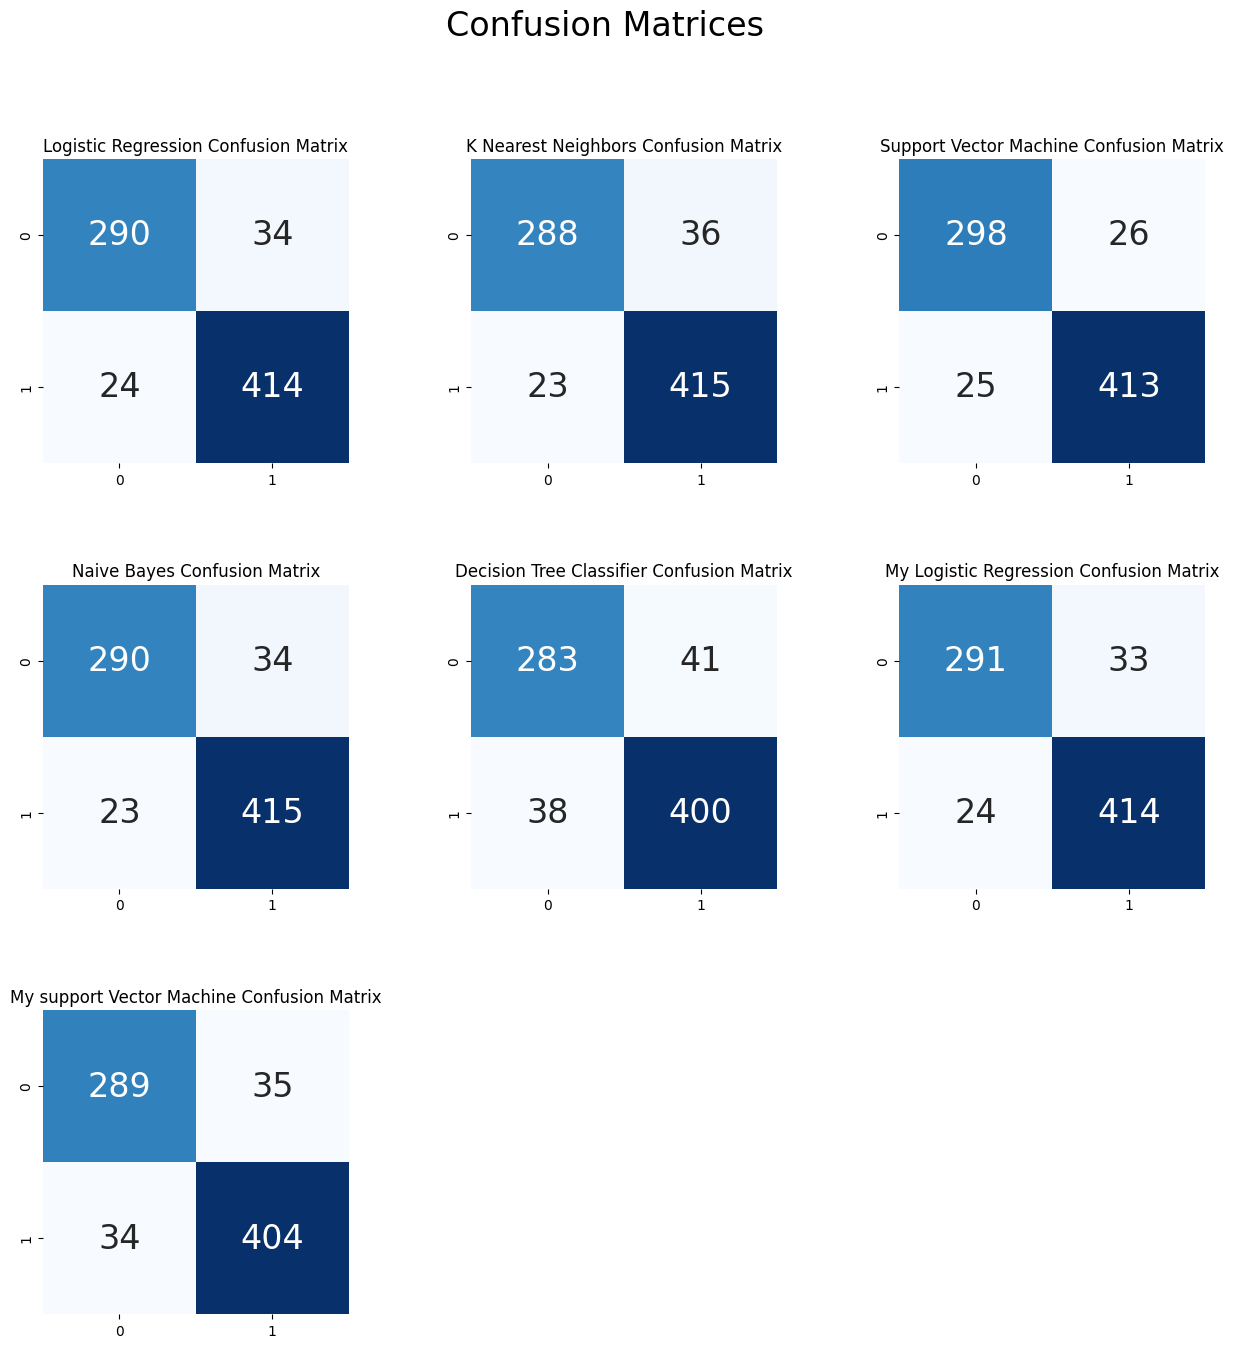

In [173]:
plt.figure(figsize=(15, 15))

plt.suptitle("Confusion Matrices", fontsize=24)
plt.subplots_adjust(wspace = 0.4, hspace= 0.4)

plt.subplot(3,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knn,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_nb,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dtc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,6)
plt.title("My Logistic Regression Confusion Matrix")
sns.heatmap(cm_my_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,7)
plt.title("My support Vector Machine Confusion Matrix")
sns.heatmap(cm_my_svc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.show()

Вывод: на втором датасете наилучшие результаты показали логистическая регрессия, KNN, SVM и собственной реализации My_LR. Самая низкая accuracy Дерево решений.